Importing the necessary Python packages into my notebook to allow for Exploratory Data Analysis.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

%matplotlib inline

Load in the workoout data in a dataframe named "gym" and checking the head of the dataframe:

In [3]:
gym = pd.read_csv('/Users/obo/Downloads/megaGymDataset.csv')
gym.head()

,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exe...,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
3,3,Banded crunch,The banded crunch is an exercise targeting the...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
4,4,Crunch,The crunch is a popular core exercise targetin...,Strength,Abdominals,Bands,Intermediate,NaN,NaN


Replaced the erroneous column with a more fitting name "Index":

In [9]:
gym.columns = gym.columns.str.replace('Unnamed: 0', 'Index')
gym.head()

,Index,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exe...,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
3,3,Banded crunch,The banded crunch is an exercise targeting the...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
4,4,Crunch,The crunch is a popular core exercise targetin...,Strength,Abdominals,Bands,Intermediate,NaN,NaN


Here I check to see the size of the dataframe to understand how much data I'm working with.

In [4]:
gym.shape

(2918, 9)

Checking to see the amount of null/missing data in the dataframe to determine whether is treatable:

In [6]:
gym.isnull().sum()

Unnamed: 0       0
Title            0
Desc          1550
Type             0
BodyPart         0
Equipment       32
Level            0
Rating        1887
RatingDesc    2056
dtype: int64

Here I look to see what data types I have because I noticed a lot of String values when checking the head of the gym dataframe:

In [7]:
gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2918 entries, 0 to 2917
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2918 non-null   int64  
 1   Title       2918 non-null   object 
 2   Desc        1368 non-null   object 
 3   Type        2918 non-null   object 
 4   BodyPart    2918 non-null   object 
 5   Equipment   2886 non-null   object 
 6   Level       2918 non-null   object 
 7   Rating      1031 non-null   float64
 8   RatingDesc  862 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 205.3+ KB


I have decided not to impute missing values because I would not be able to do a fair analysis of the data due to this nature of the missing data.

Here I begin grouping workouts by their bodyparts, levels, and need for equipment to find any underlying issues to explore:

In [11]:
ct_bodypart = gym.groupby(['BodyPart']).count()
ct_bodypart

,Index,Title,Desc,Type,Equipment,Level,Rating,RatingDesc
BodyPart,,,,,,,,
Abdominals,662,662,298,662,659,662,112,94
Abductors,21,21,8,21,21,21,10,9
Adductors,17,17,7,17,15,17,13,10
Biceps,168,168,101,168,168,168,55,53
Calves,47,47,26,47,44,47,26,26
Chest,262,262,149,262,262,262,113,90
Forearms,31,31,16,31,30,31,24,23
Glutes,81,81,29,81,81,81,25,22
Hamstrings,121,121,50,121,115,121,85,71


In [13]:
ct_levels = gym.groupby(['Level']).count()
ct_levels

,Index,Title,Desc,Type,BodyPart,Equipment,Rating,RatingDesc
Level,,,,,,,,
Beginner,459,459,108,459,459,434,459,369
Expert,13,13,10,13,13,13,7,7
Intermediate,2446,2446,1250,2446,2446,2439,565,486


In [14]:
ct_equipment = gym.groupby(['Equipment']).count()
ct_equipment

,Index,Title,Desc,Type,BodyPart,Level,Rating,RatingDesc
Equipment,,,,,,,,
Bands,100,100,49,100,100,100,30,20
Barbell,282,282,161,282,282,282,180,168
Body Only,1078,1078,404,1078,1078,1078,269,196
Cable,226,226,149,226,226,226,77,77
Dumbbell,516,516,246,516,516,516,140,129
E-Z Curl Bar,22,22,14,22,22,22,11,11
Exercise Ball,35,35,28,35,35,35,12,11
Foam Roll,11,11,8,11,11,11,9,9
Kettlebells,149,149,53,149,149,149,57,39


I've created a bar chart here that would show the distribution of the number of exercises to body parts.

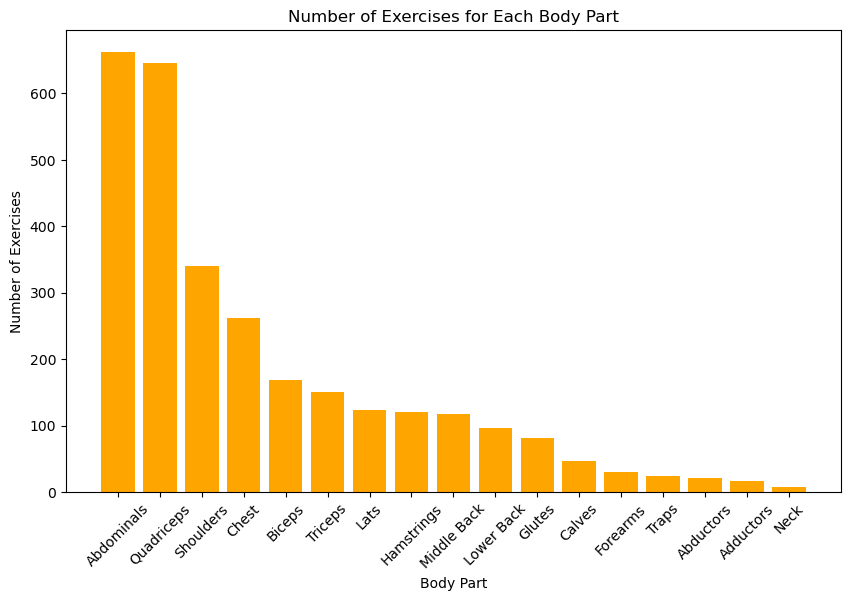

In [25]:
ct_bodypart = ct_bodypart.sort_values(by='Index', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(ct_bodypart.index, ct_bodypart['Index'], color='orange')
plt.xlabel('Body Part')
plt.ylabel('Number of Exercises')
plt.title('Number of Exercises for Each Body Part')
plt.xticks(rotation=45)
plt.show()

Here I created two slices of my gym data frame to further explore my goal of recommeding the best exercises to beginnger and intermediate gym goers.

In [27]:
beginner = gym[gym['Level'] == 'Beginner']
beginner.head()

,Index,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
11,11,Bench barbell roll-out,The bench barbell roll-out is a challenging ex...,Strength,Abdominals,Barbell,Beginner,8.3,Average
12,12,Barbell Side Bend,NaN,Strength,Abdominals,Barbell,Beginner,7.0,Average
20,20,Advanced Kettlebell Windmill,NaN,Strength,Abdominals,Kettlebells,Beginner,8.3,Average
22,22,Kettlebell Pass Between The Legs,NaN,Strength,Abdominals,Kettlebells,Beginner,7.3,Average
40,40,Dumbbell spell caster,The dumbbell spell caster is an exercise that ...,Strength,Abdominals,Dumbbell,Beginner,9.3,Average


In [28]:
intermediate = gym[gym['Level'] == 'Intermediate']
intermediate.head()

,Index,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exe...,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
3,3,Banded crunch,The banded crunch is an exercise targeting the...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
4,4,Crunch,The crunch is a popular core exercise targetin...,Strength,Abdominals,Bands,Intermediate,NaN,NaN


I wanted to gain a better understanding of how many exercises catered to each experience level to see how that may make me adjust any further recommendations.

Text(0.5, 1.0, 'Percentage of Exercises for Each Experience Level')

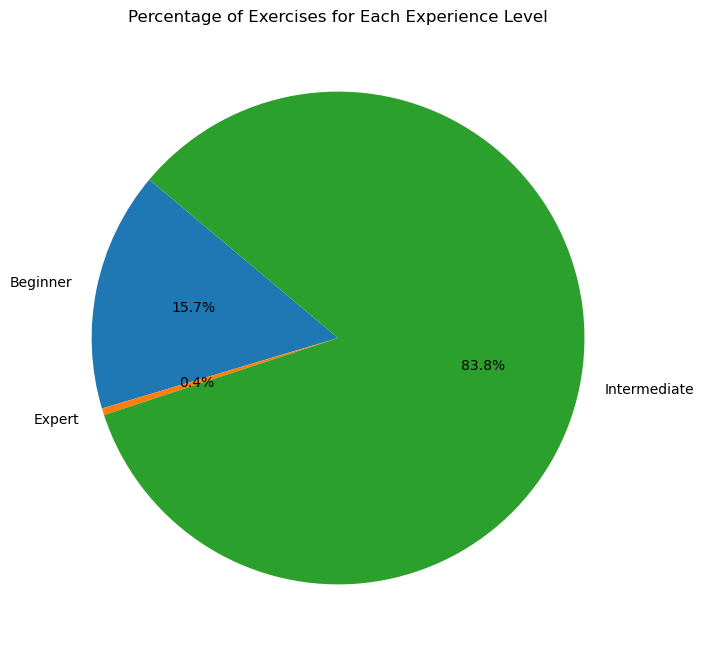

In [29]:
plt.figure(figsize=(8,8))
plt.pie(ct_levels['Index'], labels=ct_levels.index, autopct='%1.1f%%', startangle=140)
plt.title('Percentage of Exercises for Each Experience Level')

Lastly, I created the recommendation charts I sought to make for beginner and intermediate gym goers while also warning them of the worst exercises for them to do.

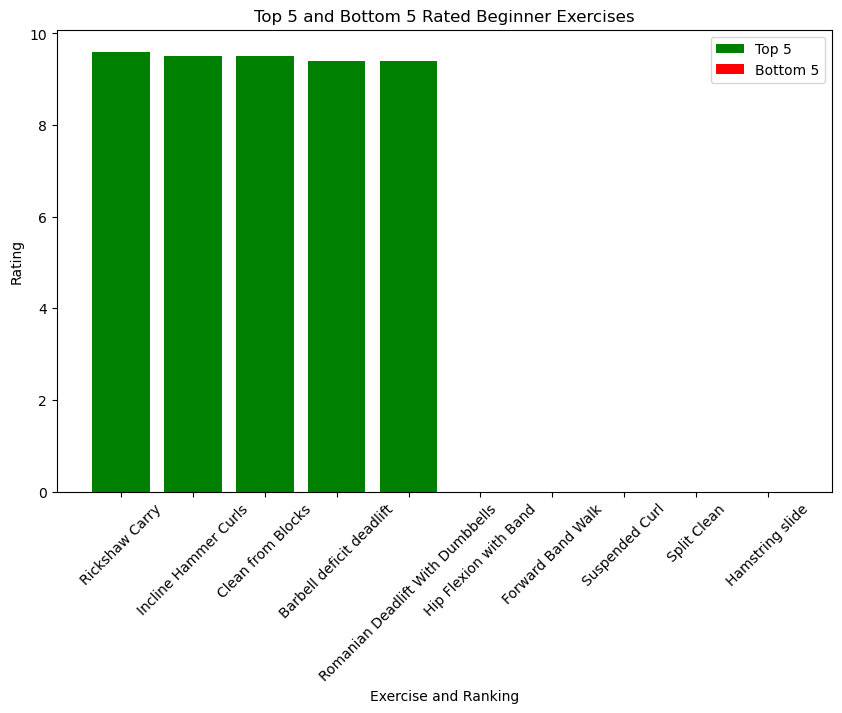

In [46]:
beginner_rtg = gym[gym['Level'] == 'Beginner'].sort_values(by='Rating', ascending=False)
best_beginner = beginner_rtg.head(5)

worst_beginner = beginner_rtg.tail(5)

plt.figure(figsize=(10, 6))
plt.bar(best_beginner.Title, best_beginner.Rating, color='green', label='Top 5')
plt.bar(worst_beginner.Title, worst_beginner.Rating, color='red', label='Bottom 5')
plt.xlabel('Exercise and Ranking')
plt.ylabel('Rating')
plt.title('Top 5 and Bottom 5 Rated Beginner Exercises')
plt.xticks(rotation=45)
plt.legend()
plt.show()

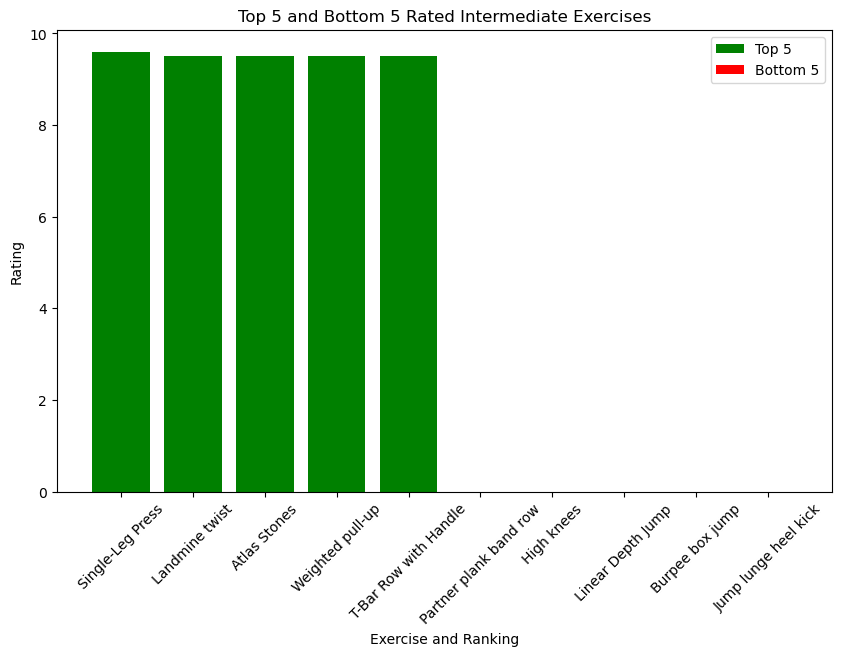

In [57]:
intermediate_rtg = gym[gym['Level'] == 'Intermediate'].sort_values(by='Rating', ascending=False)
best_intermediate = intermediate_rtg.head(5)

wst_intermediate_rtg = gym[gym['Level'] == 'Intermediate'].sort_values(by='Rating', ascending=True)
worst_intermediate = wst_intermediate_rtg.head(5)

plt.figure(figsize=(10, 6))
plt.bar(best_intermediate.Title, best_intermediate.Rating, color='green', label='Top 5')
plt.bar(worst_intermediate.Title, worst_intermediate.Rating, color='red', label='Bottom 5')
plt.xlabel('Exercise and Ranking')
plt.ylabel('Rating')
plt.title('Top 5 and Bottom 5 Rated Intermediate Exercises')
plt.xticks(rotation=45)
plt.legend()
plt.show()